# Documentaion

# Data Quality Check

Before starting the preprocessing phase, the dataset was checked for common data quality issues.

-  No missing values were found in any column.
-  No duplicate records were detected in the dataset.

These checks confirmed that the dataset was complete and ready for further preprocessing.

---

# Data Cleaning & Preparation

### 1. BMI Validation
- Recalculated the **Body Mass Index (BMI)** using the standard formula:

  \[
  BMI = \frac{Weight\ (kg)}{Height^2\ (m)}
  \]

- Compared the calculated BMI with the existing `BMI` column to verify data consistency.

---

### 2. Converted `Position` to a Categorical Variable
- Converted the `Position` column from `object` to the **categorical** data type for improved memory efficiency and easier analysis.

---

### 3. Feature Mapping
To improve dashboard readability and make the analysis more interpretable, several numerical features were grouped into meaningful categories:

- **TrainingLevel**
- **Sleep_Category**
- **Matches_Load**
- **Injury_History**
- **Nutrition_Category**
- **Injury_Status**

> The original numerical columns were retained for machine learning purposes.

---

### 4. Distribution Analysis
- Examined the distribution of all numerical features.
- Most variables exhibited an approximately **normal distribution**, making them suitable for statistical analysis and machine learning.

---

### 5. Outlier Analysis
- Outliers were identified in several numerical features through visualization.
- These observations represent natural variations among athletes rather than data entry errors.
- Therefore, **no outliers were removed**, ensuring that valuable information was preserved for both dashboard analysis and machine learning.


## Variables Positively Correlated with Injury Risk

The following variables show a positive correlation with **Injury_Next_Season**, indicating that higher values are associated with a greater likelihood of injury:

- **Stress_Level_Score** (**r = 0.53**)
- **Reaction_Time_ms** (**r = 0.47**)
- **Previous_Injury_Count** (**r = 0.38**)

## Variables Negatively Correlated with Injury Risk

The following variables show a negative correlation with **Injury_Next_Season**, indicating that higher values are associated with a lower likelihood of injury:

- **Sleep_Hours_Per_Night** (**r = -0.51**)
- **Balance_Test_Score** (**r = -0.49**)
- **Sprint_Speed_10m_s** (**r = -0.47**)
- **Knee_Strength_Score** (**r = -0.45**)
- **Hamstring_Flexibility** (**r = -0.45**)
- **Nutrition_Quality_Score** (**r = -0.41**)
- **Agility_Score** (**r = -0.39**)
- **Warmup_Routine_Adherence** (**r = -0.27**)

## import libraries and load data

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df=pd.read_csv("/content/data.csv")

## Explore Data

In [31]:
df.head()

,Age,Height_cm,Weight_kg,Position,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI
0,22,173,64,Midfielder,11.575308,36,1,77.460279,79.115738,284.487853,91.212476,5.874630,77.599705,8.238293,46.616415,81.472206,1,0,21.383942
1,18,170,67,Midfielder,12.275869,37,2,72.634442,82.541688,250.579249,87.294078,5.796269,94.418987,8.983737,49.368037,81.056677,1,0,23.183391
2,22,186,75,Forward,12.254896,12,2,77.064490,75.943631,269.119918,83.440688,5.731209,70.179176,7.229193,43.132808,64.877457,0,1,21.678807
3,20,172,62,Defender,9.006678,11,1,82.810232,73.878324,226.376412,87.591894,6.220212,83.473824,7.681029,51.528529,89.824744,1,0,20.957274
4,18,172,94,Midfielder,12.683668,10,2,76.772859,76.653043,229.021042,83.125161,5.385958,87.037256,6.728091,52.379718,71.569197,0,1,31.773932


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         800 non-null    int64  
 1   Height_cm                   800 non-null    int64  
 2   Weight_kg                   800 non-null    int64  
 3   Position                    800 non-null    object 
 4   Training_Hours_Per_Week     800 non-null    float64
 5   Matches_Played_Past_Season  800 non-null    int64  
 6   Previous_Injury_Count       800 non-null    int64  
 7   Knee_Strength_Score         800 non-null    float64
 8   Hamstring_Flexibility       800 non-null    float64
 9   Reaction_Time_ms            800 non-null    float64
 10  Balance_Test_Score          800 non-null    float64
 11  Sprint_Speed_10m_s          800 non-null    float64
 12  Agility_Score               800 non-null    float64
 13  Sleep_Hours_Per_Night       800 non

In [33]:
df.isnull().sum()

,0
Age,0
Height_cm,0
Weight_kg,0
Position,0
Training_Hours_Per_Week,0
Matches_Played_Past_Season,0
Previous_Injury_Count,0
Knee_Strength_Score,0
Hamstring_Flexibility,0
Reaction_Time_ms,0


In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
#check BMI column
df['check_BMI']=df['Weight_kg']/((df['Height_cm']/100)**2)

In [36]:
df[df['BMI'].round(2)!=df['check_BMI'].round(2)]

,Age,Height_cm,Weight_kg,Position,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI,check_BMI


In [37]:
df.drop('check_BMI',inplace=True,axis=1)

## Modify data types

In [38]:
df['Position']=df['Position'].astype("category")

In [39]:
df.describe()

,Age,Height_cm,Weight_kg,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,21.135000,177.407500,73.235000,9.951150,22.332500,1.536250,74.933249,79.154123,249.423244,83.832337,5.949025,78.341311,7.417124,54.039342,74.382174,0.597500,0.500000,23.377364
std,1.991037,7.148974,9.929276,2.610395,10.311516,1.292584,6.672704,6.782332,22.532387,6.931657,0.329133,8.775418,0.793183,11.421143,9.324899,0.490708,0.500313,3.673279
min,18.000000,154.000000,45.000000,5.000000,5.000000,0.000000,52.391351,58.180381,180.000000,60.059484,4.862435,50.000000,5.000000,21.561186,50.000000,0.000000,0.000000,14.346326
25%,19.000000,173.000000,66.000000,8.127151,13.000000,1.000000,70.432656,74.495959,234.089585,79.044910,5.732552,72.675392,6.850062,45.775371,67.809084,0.000000,0.000000,20.786644
50%,21.000000,177.000000,73.000000,9.895710,22.000000,1.000000,74.997933,79.187909,249.127328,84.156236,5.937692,78.340973,7.424618,54.047208,74.363878,1.000000,0.500000,23.130560
75%,23.000000,182.000000,80.000000,11.535140,32.000000,2.000000,79.632391,83.813179,265.105082,88.877902,6.159205,84.093489,7.988100,61.910804,80.502613,1.000000,1.000000,26.024182
max,24.000000,200.000000,105.000000,18.866608,39.000000,8.000000,93.900051,100.000000,306.730851,100.000000,6.898228,100.000000,9.860553,87.065007,100.000000,1.000000,1.000000,36.262439


## Distribution Analysis

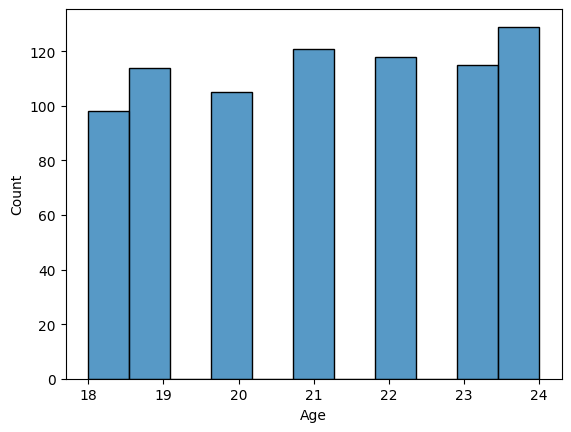

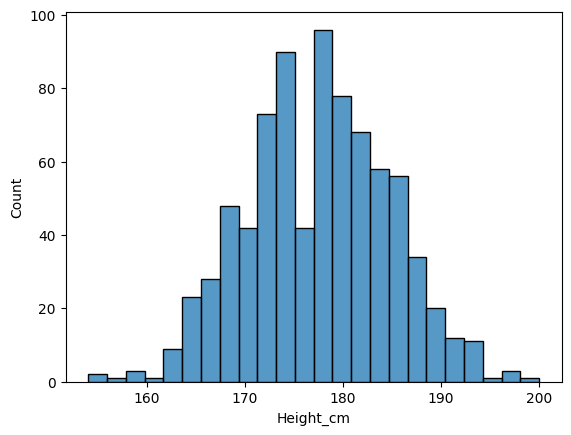

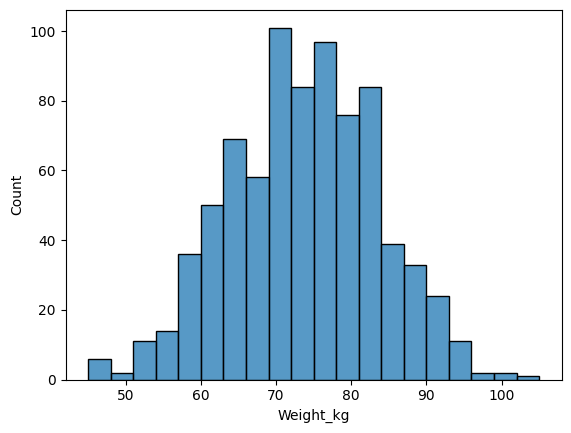

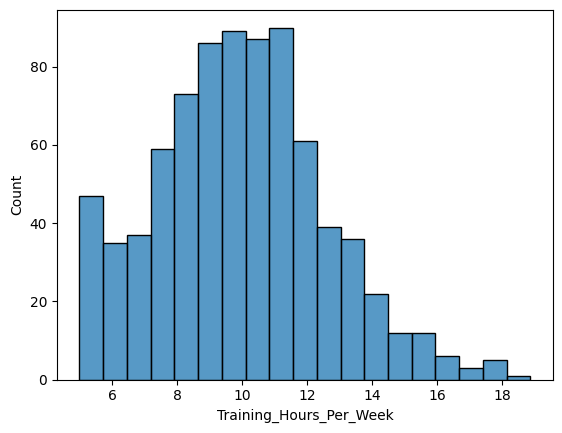

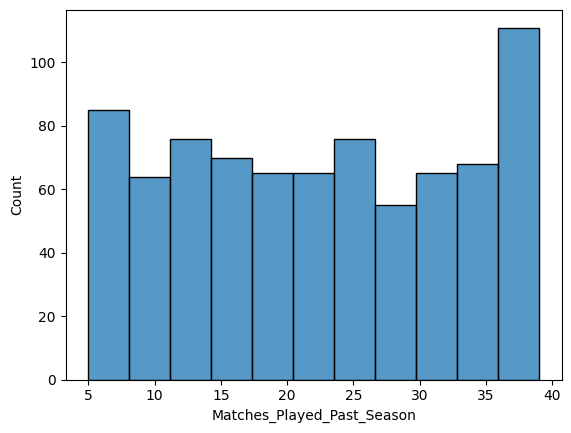

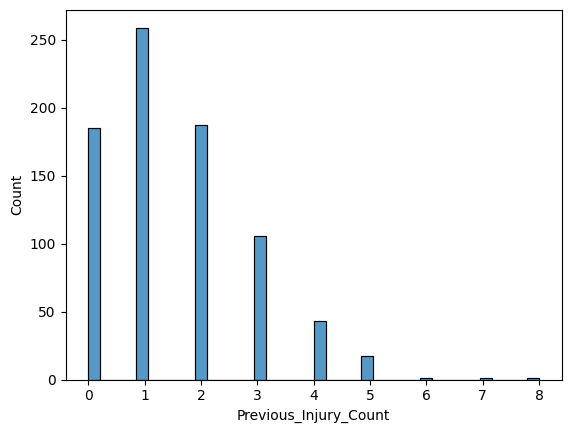

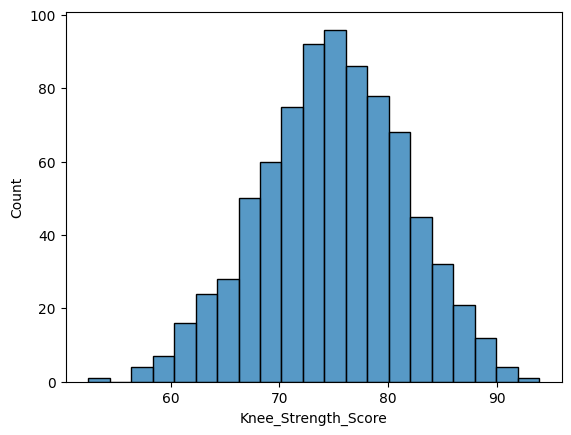

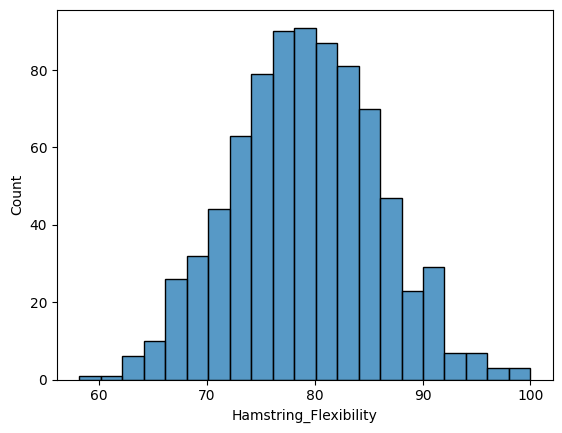

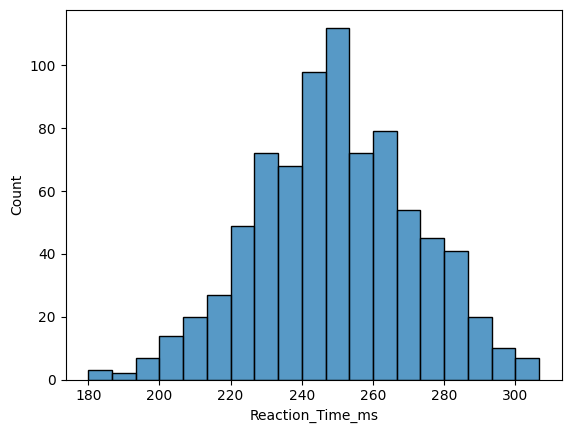

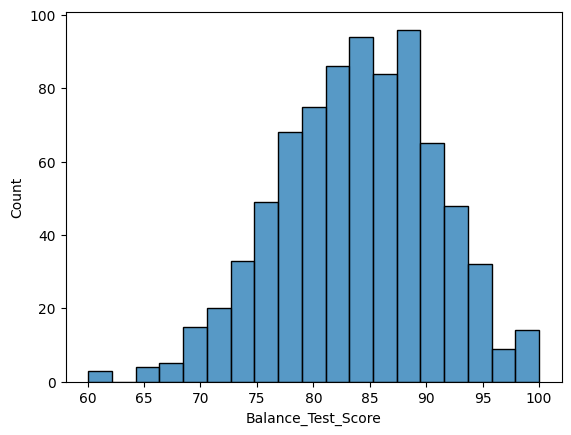

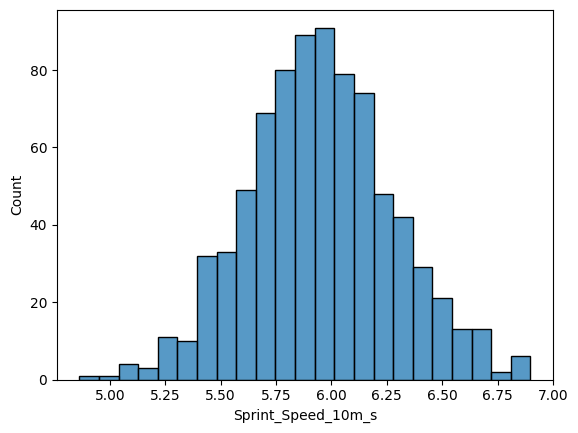

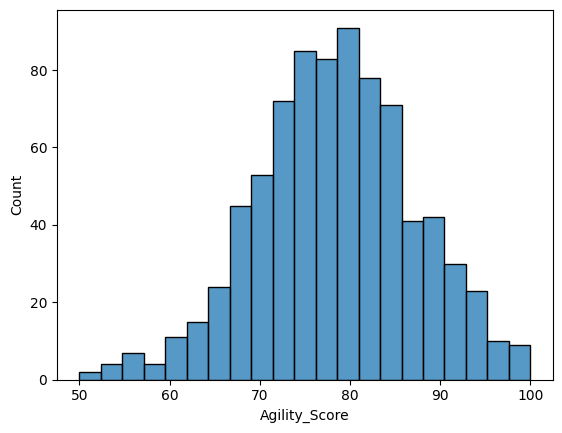

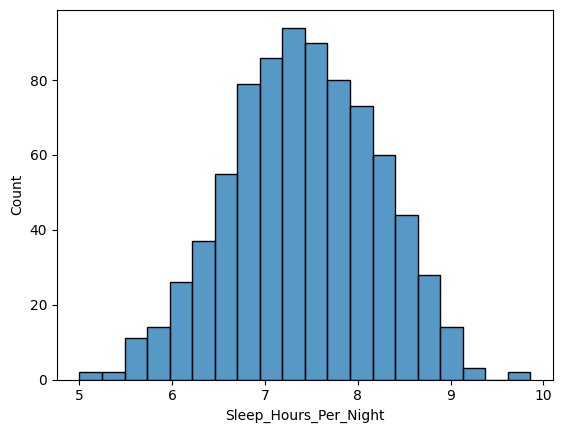

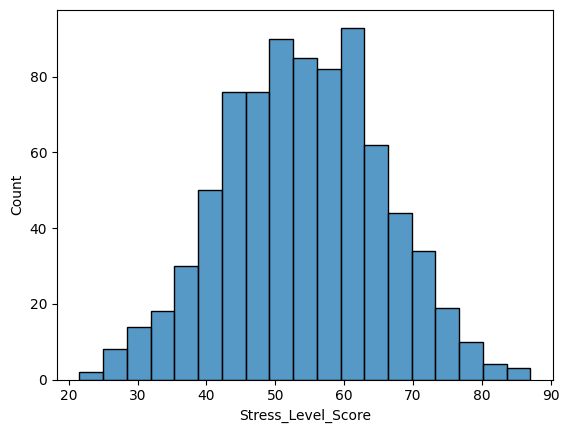

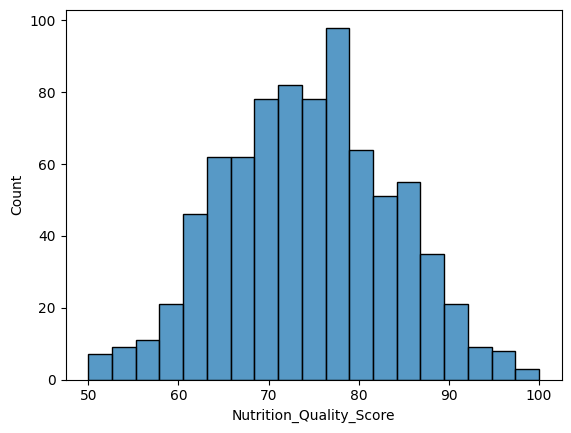

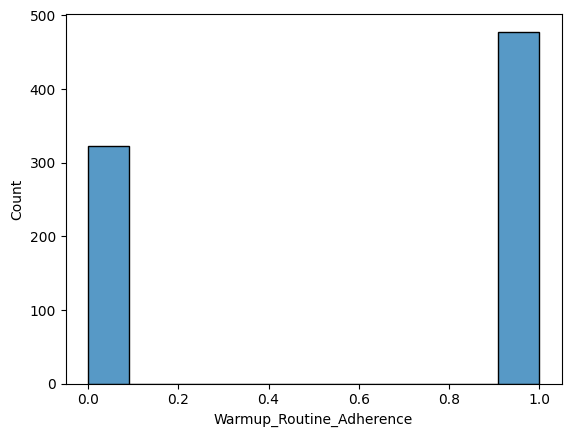

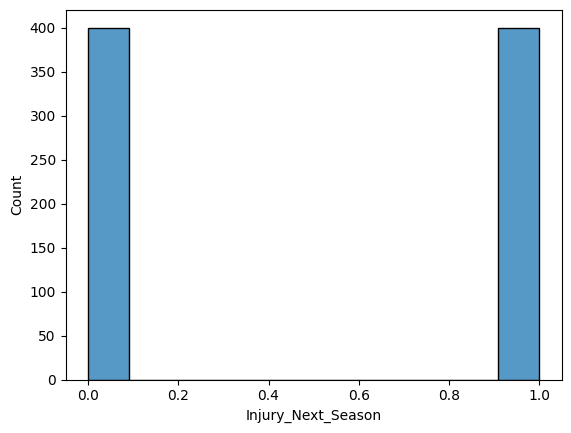

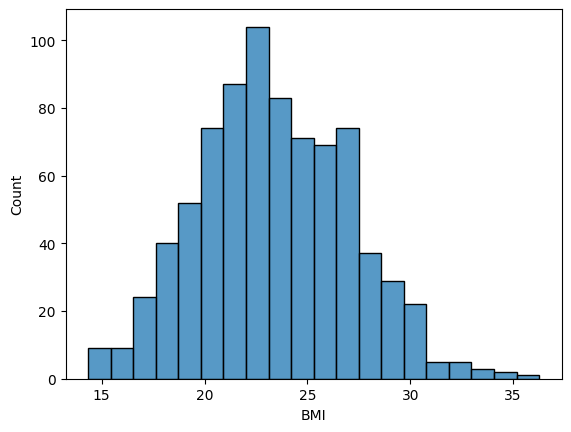

In [40]:
# check distribution
for i in df.select_dtypes(include='number').columns:
  sns.histplot(data=df,x=i)
  plt.show()

## Check Outliers

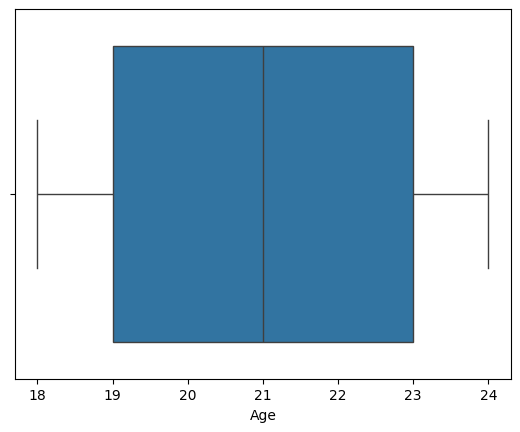

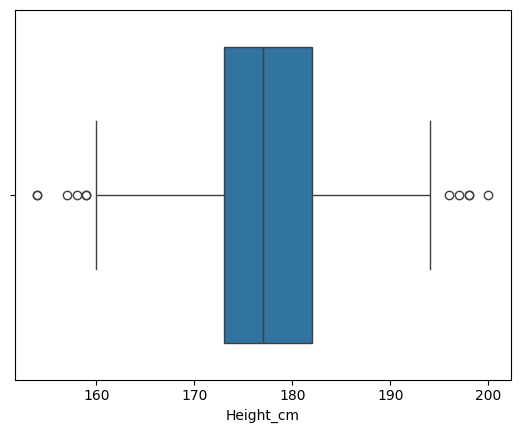

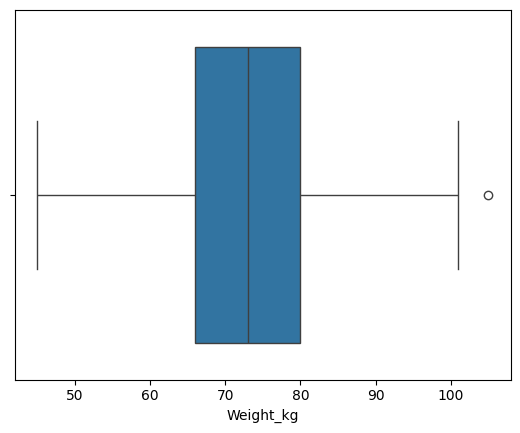

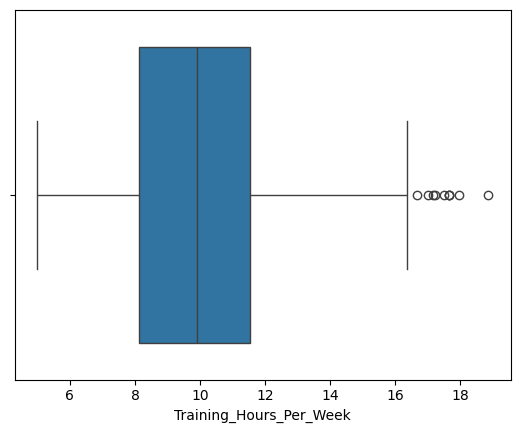

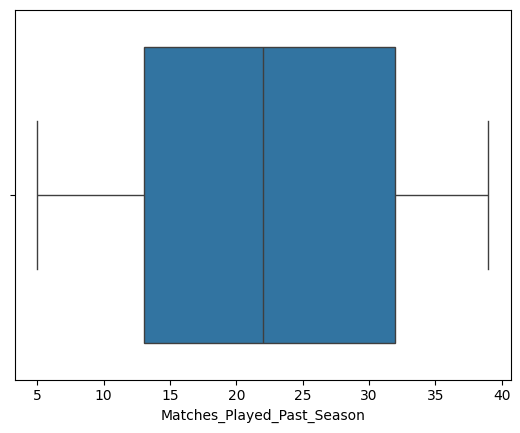

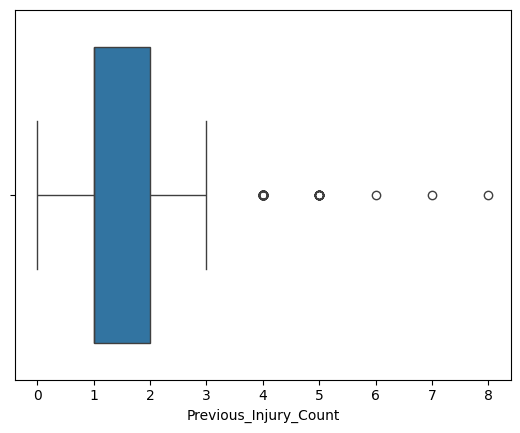

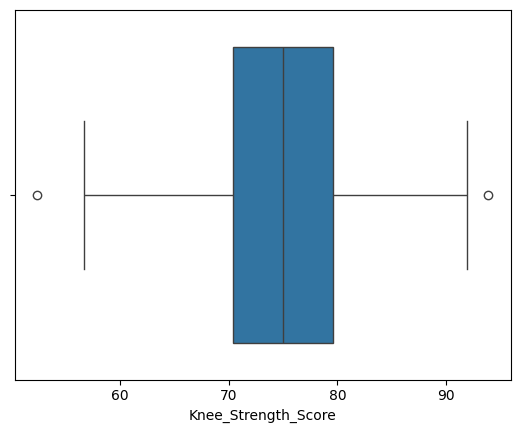

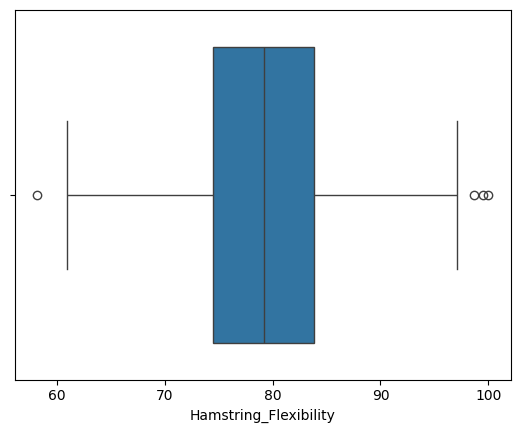

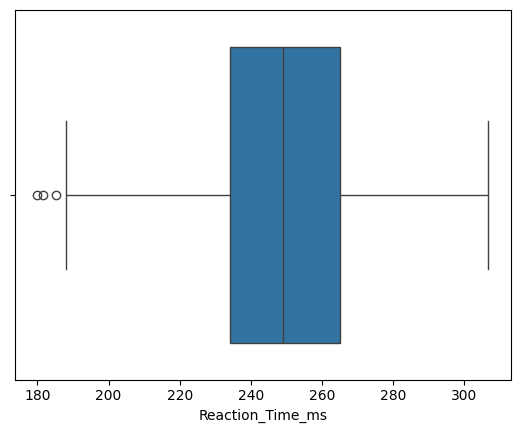

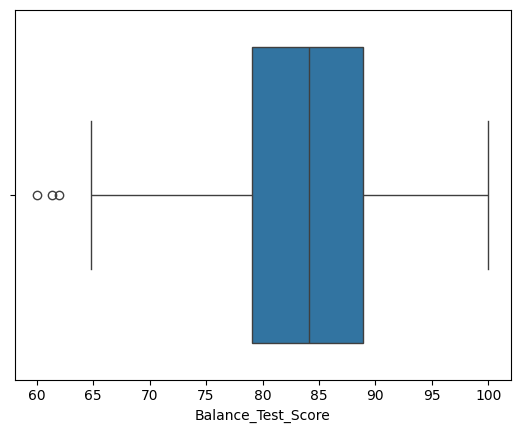

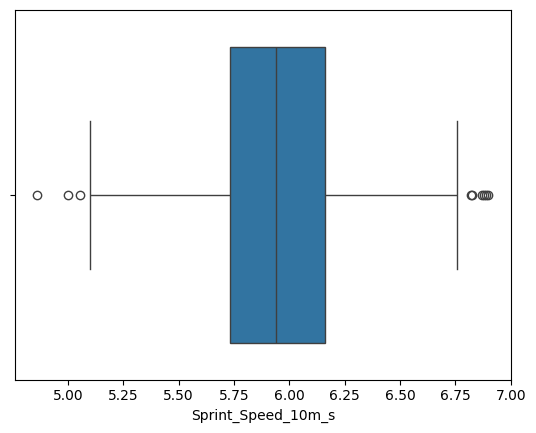

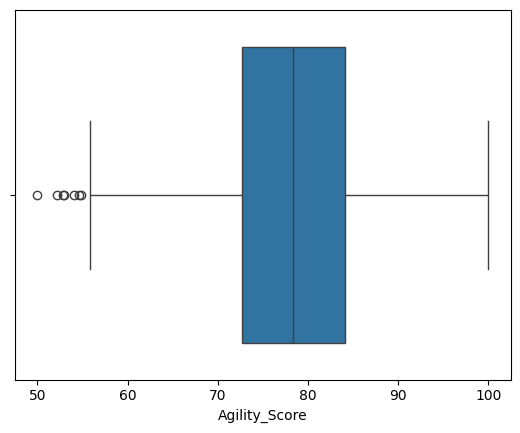

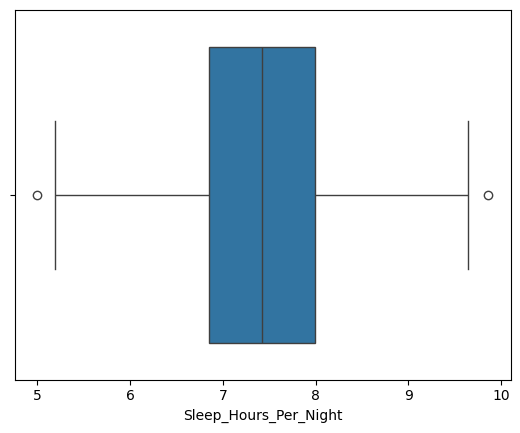

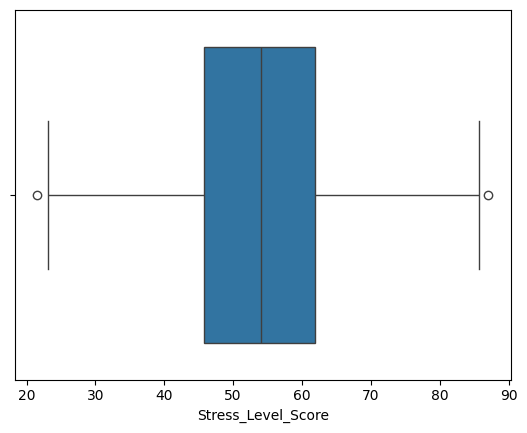

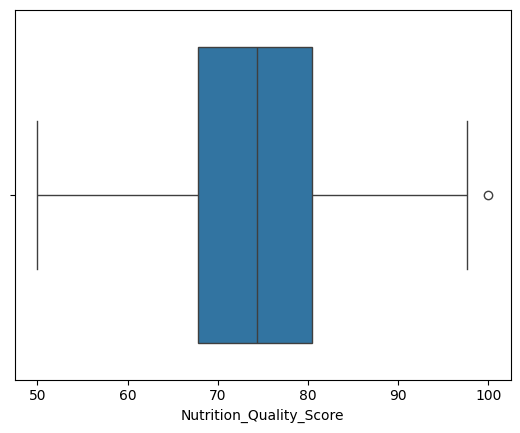

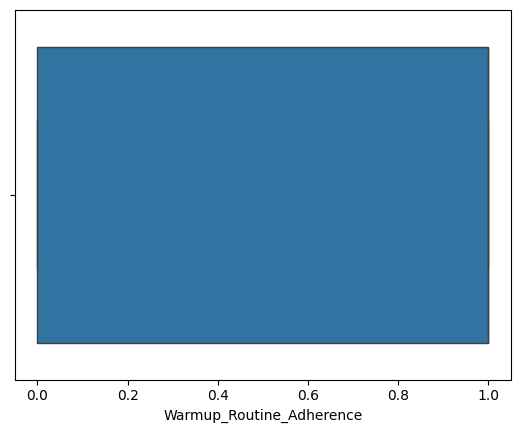

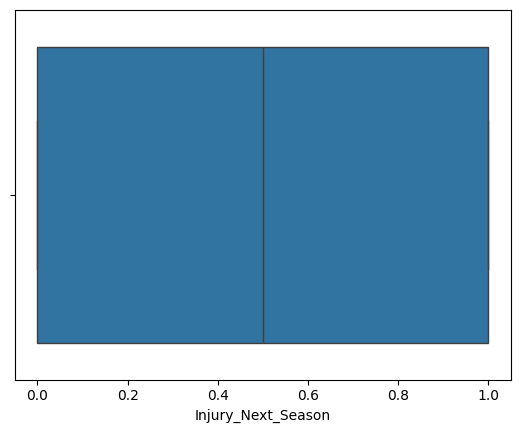

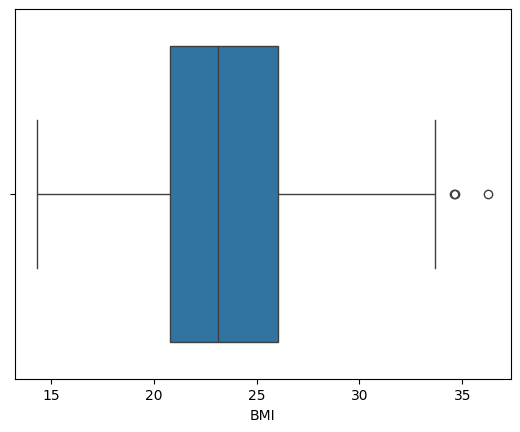

In [41]:
for i in df.select_dtypes(include='number').columns:
  sns.boxplot(data=df,x=i)
  plt.show()

## Find Correlations

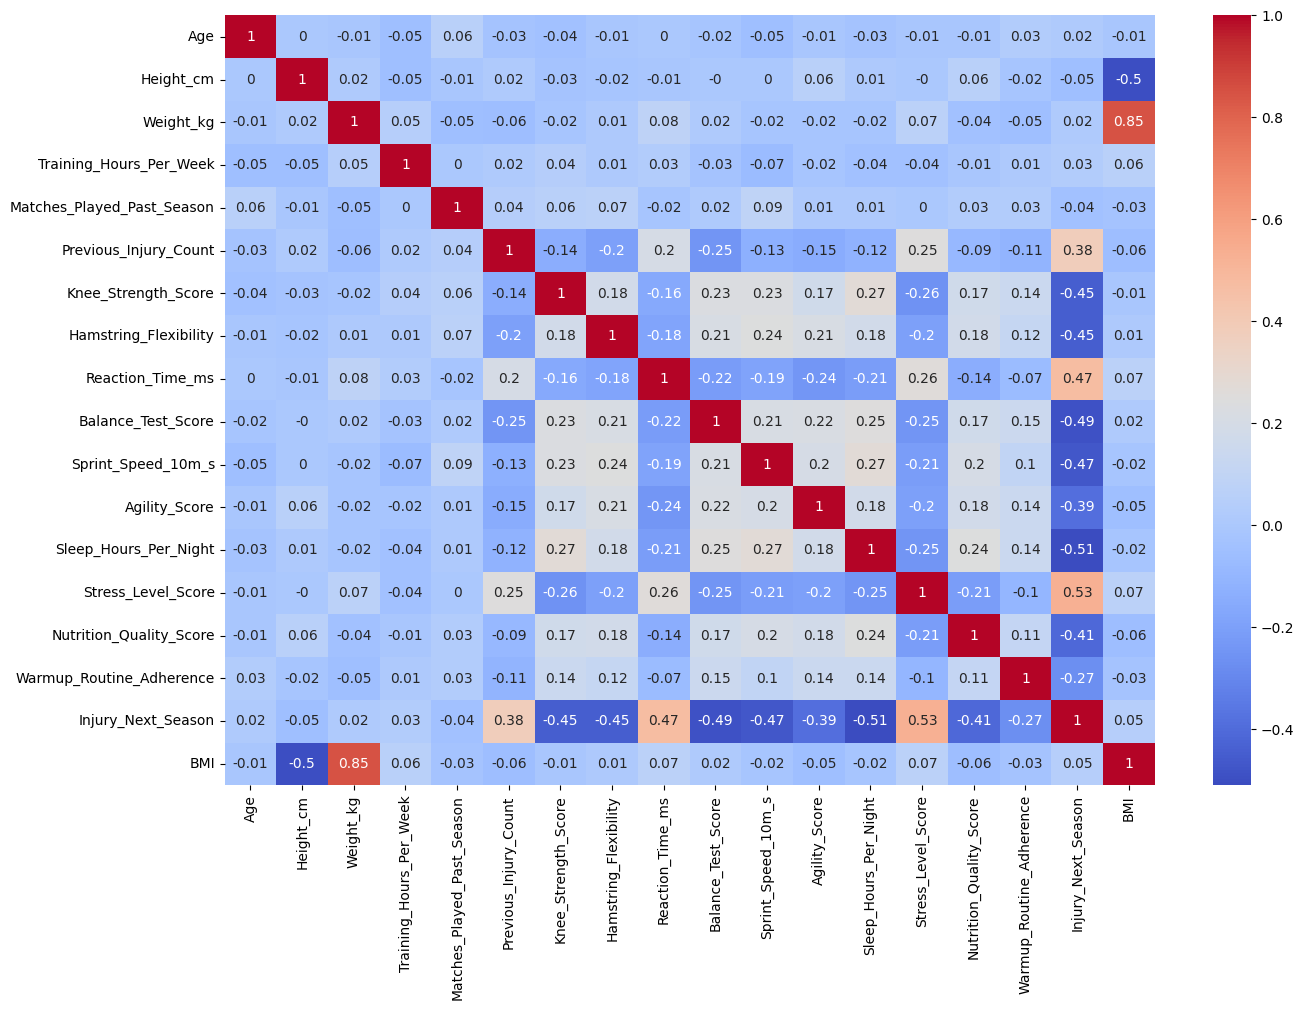

In [42]:
s= df.select_dtypes(include='number').corr().round(2)
plt.figure(figsize=(15,10))
sns.heatmap(s,annot=True,cmap="coolwarm")
plt.show()

In [43]:
df.head()

,Age,Height_cm,Weight_kg,Position,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI
0,22,173,64,Midfielder,11.575308,36,1,77.460279,79.115738,284.487853,91.212476,5.874630,77.599705,8.238293,46.616415,81.472206,1,0,21.383942
1,18,170,67,Midfielder,12.275869,37,2,72.634442,82.541688,250.579249,87.294078,5.796269,94.418987,8.983737,49.368037,81.056677,1,0,23.183391
2,22,186,75,Forward,12.254896,12,2,77.064490,75.943631,269.119918,83.440688,5.731209,70.179176,7.229193,43.132808,64.877457,0,1,21.678807
3,20,172,62,Defender,9.006678,11,1,82.810232,73.878324,226.376412,87.591894,6.220212,83.473824,7.681029,51.528529,89.824744,1,0,20.957274
4,18,172,94,Midfielder,12.683668,10,2,76.772859,76.653043,229.021042,83.125161,5.385958,87.037256,6.728091,52.379718,71.569197,0,1,31.773932


In [44]:
position_counts=df['Position'].value_counts()

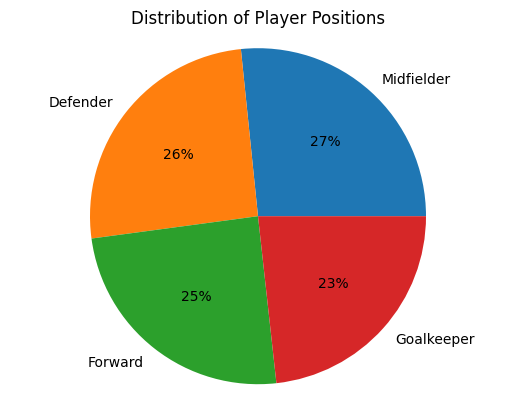

In [45]:
plt.pie(position_counts,labels=position_counts.index,autopct="%1.0f%%")
plt.title("Distribution of Player Positions")
plt.axis("equal")
plt.show()

## Feature Engineering

In [46]:
df[['Training_Hours_Per_Week','Sleep_Hours_Per_Night','Matches_Played_Past_Season','Nutrition_Quality_Score']].describe()

,Training_Hours_Per_Week,Sleep_Hours_Per_Night,Matches_Played_Past_Season,Nutrition_Quality_Score
count,800.000000,800.000000,800.000000,800.000000
mean,9.951150,7.417124,22.332500,74.382174
std,2.610395,0.793183,10.311516,9.324899
min,5.000000,5.000000,5.000000,50.000000
25%,8.127151,6.850062,13.000000,67.809084
50%,9.895710,7.424618,22.000000,74.363878
75%,11.535140,7.988100,32.000000,80.502613
max,18.866608,9.860553,39.000000,100.000000


In [47]:
df['TrainingLevel']=pd.cut(
    df['Training_Hours_Per_Week'],
    bins = [4,8,11,14,float("inf")],
    labels=['Low',"Moderate","High","Very High"],
    include_lowest=True
)

In [48]:
df['Sleep_Category']=pd.cut(
    df['Sleep_Hours_Per_Night'],
    bins=[4,7,9,float("inf")],
    labels=["Poor", "Normal", "High"],
    include_lowest=True
)

In [49]:
df['Matches_Load']=pd.cut(
    df['Matches_Played_Past_Season'],
    bins=[4, 12, 22, 32, float("inf")],
    labels=['Low',"Moderate","High","Very High"],
    include_lowest=True
)

In [50]:
df["Injury_History"] = pd.cut(
    df["Previous_Injury_Count"],
    bins=[-1, 0, 2, float("inf")],
    labels=[
        "No Previous Injury",
        "Few Injuries",
        "Frequent Injuries"
    ]
)

In [51]:
df["Nutrition_Category"] = pd.cut(
    df["Nutrition_Quality_Score"],
    bins=[49, 60, 75, 90, 100],
    labels=["Poor", "Average", "Good", "Excellent"],
    include_lowest=True
)

In [52]:
df["Injury_Status"] = df["Injury_Next_Season"].map({
    0: "No Injury",
    1: "Injured"
})

In [53]:
df.to_csv("Cleaned_data.csv")